# **IMPORT LIBRARY**

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
sns.set(style="whitegrid")

In [76]:
# Membaca dataset
df = pd.read_csv('dataset_jagung.csv')
df.head()

,Temperature,Humidity,Soil_Moisture,Growth
0,19.363503,41.107976,17.851171,70.347851
1,33.767858,62.514057,17.409364,102.322386
2,28.299849,82.376750,37.187637,121.872884
3,24.966462,73.933493,17.486386,91.019964
4,13.900466,78.393669,18.158492,94.534460


In [77]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    1000 non-null   float64
 1   Humidity       1000 non-null   float64
 2   Soil_Moisture  1000 non-null   float64
 3   Growth         1000 non-null   float64
dtypes: float64(4)
memory usage: 31.4 KB


,Temperature,Humidity,Soil_Moisture,Growth
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,22.256414,60.421038,25.072172,87.592048
std,7.303434,17.531394,8.720226,17.971800
min,10.115801,30.193096,10.000349,36.965558
25%,15.899332,44.464456,17.840529,74.650367
50%,22.420184,61.124034,25.018418,87.542517
75%,28.607990,75.627903,32.773106,101.076906
max,34.992942,89.964824,39.934626,136.309728


In [78]:
missing_data = df.isnull().sum()

print("Jumlah Missing Values per Kolom:")
print(missing_data)

Jumlah Missing Values per Kolom:
Temperature      0
Humidity         0
Soil_Moisture    0
Growth           0
dtype: int64


In [100]:
total_duplikat = df_clean.duplicated().sum()
print(f"Total data duplikat: {total_duplikat}")

if total_duplikat > 0:
    print("\nBaris data yang duplikat:")
    display(df_clean[df_clean.duplicated()])
    df_clean = df_clean.drop_duplicates()
    print("\nData duplikat telah dihapus.")
    print(f"Ukuran dataset sekarang: {df_clean.shape}")
else:
    print("\nTidak ditemukan data duplikat. Dataset bersih.")

Total data duplikat: 0

Tidak ditemukan data duplikat. Dataset bersih.


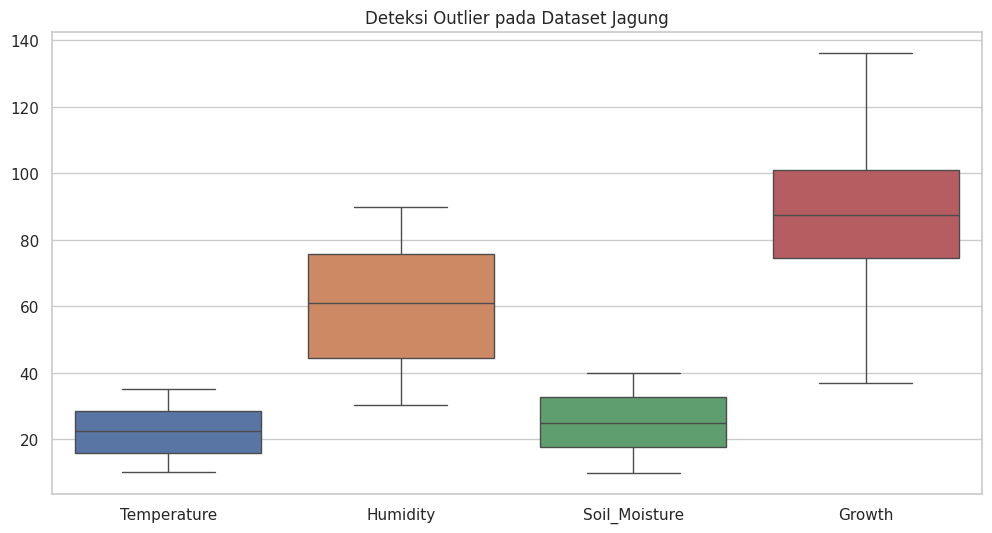

In [79]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Deteksi Outlier pada Dataset Jagung")
plt.show()

In [80]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

print(f"Jumlah data sebelum dibersihkan: {len(df)}")
print(f"Jumlah data setelah outlier dihapus: {len(df_clean)}")

Jumlah data sebelum dibersihkan: 1000
Jumlah data setelah outlier dihapus: 1000


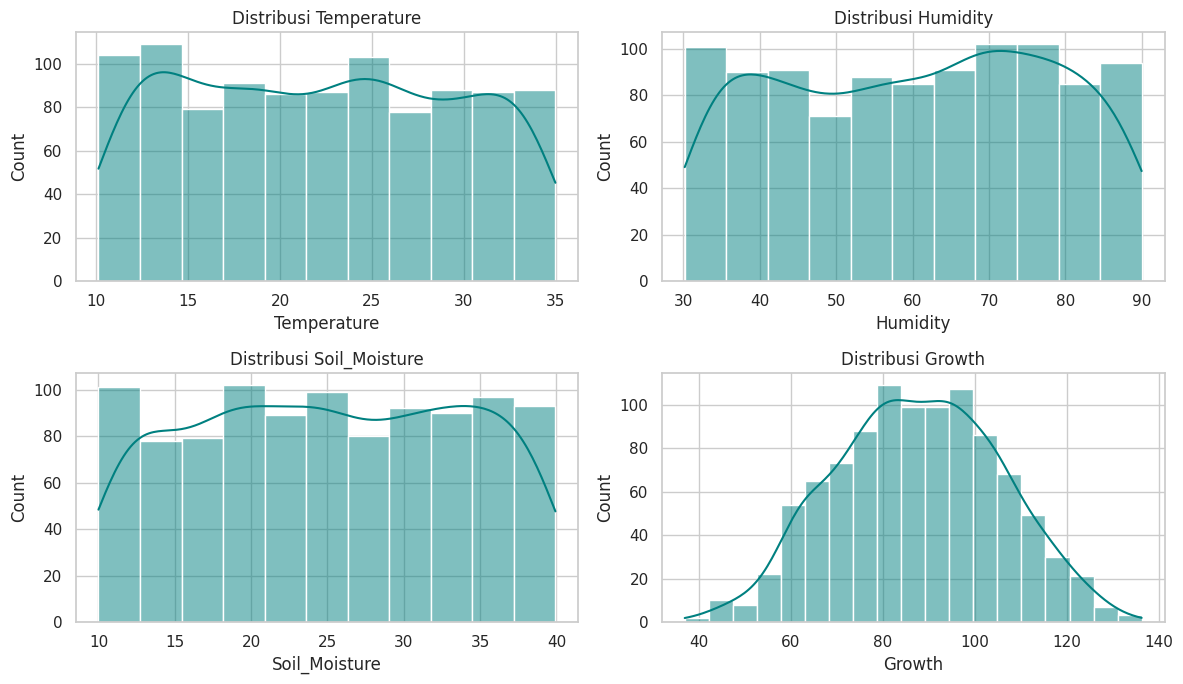

In [81]:
# Membuat plot distribusi untuk setiap kolom
plt.figure(figsize=(12, 7))

for i, col in enumerate(df_clean.columns):
    plt.subplot(2, 2, i+1)
    sns.histplot(df_clean[col], kde=True, color='teal')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

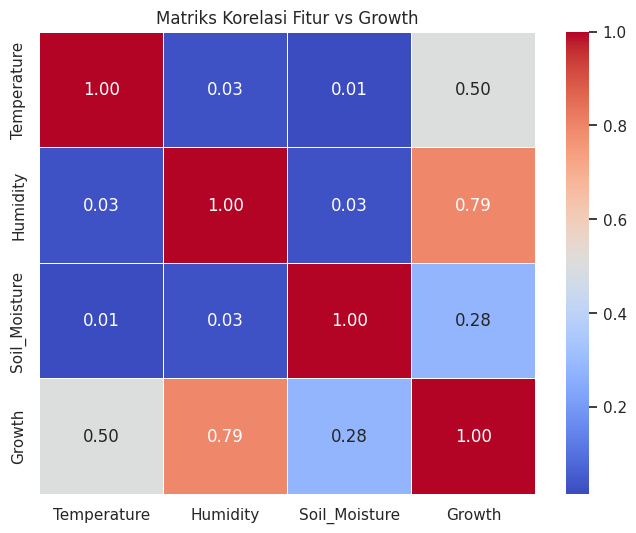

In [82]:
# Menghitung matriks korelasi
plt.figure(figsize=(8, 6))
correlation_matrix = df_clean.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Fitur vs Growth")
plt.show()

In [83]:
print("--- INSIGHT PENTING DATASET JAGUNG ---")
correlations = df_clean.corr()['Growth'].sort_values(ascending=False)
top_feature = correlations.index[1]
top_value = correlations.values[1]

print(f"1. Faktor yang paling memengaruhi pertumbuhan adalah '{top_feature}' "
      f"dengan korelasi sebesar {top_value:.2f}.")

avg_temp = df_clean['Temperature'].mean()
avg_hum = df_clean['Humidity'].mean()

print(f"2. Kondisi rata-rata pada dataset: Suhu {avg_temp:.2f}°C "
      f"dan Kelembapan {avg_hum:.2f}%.")

for col in df_clean.columns:
    skewness = df_clean[col].skew()
    status = "Normal" if abs(skewness) < 0.5 else "Miring (Skewed)"
    print(f"3. Distribusi kolom '{col}' bersifat {status} (Skewness: {skewness:.2f}).")

n_outliers = len(df) - len(df_clean)
print(f"4. Ditemukan {n_outliers} data anomali (outlier) yang telah dibersihkan "
      f"untuk menjaga kestabilan model.")

print("-" * 40)

--- INSIGHT PENTING DATASET JAGUNG ---
1. Faktor yang paling memengaruhi pertumbuhan adalah 'Humidity' dengan korelasi sebesar 0.79.
2. Kondisi rata-rata pada dataset: Suhu 22.26°C dan Kelembapan 60.42%.
3. Distribusi kolom 'Temperature' bersifat Normal (Skewness: 0.04).
3. Distribusi kolom 'Humidity' bersifat Normal (Skewness: -0.06).
3. Distribusi kolom 'Soil_Moisture' bersifat Normal (Skewness: -0.02).
3. Distribusi kolom 'Growth' bersifat Normal (Skewness: -0.02).
4. Ditemukan 0 data anomali (outlier) yang telah dibersihkan untuk menjaga kestabilan model.
----------------------------------------


In [96]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

poly_features_names = poly.get_feature_names_out(X.columns)

In [85]:
# Variasi 1: 70:30
X_train70, X_test70, y_train70, y_test70 = train_test_split(X_poly, y, test_size=0.3, random_state=42)

# Variasi 2: 80:20
X_train80, X_test80, y_train80, y_test80 = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Variasi 3: 90:10
X_train90, X_test90, y_train90, y_test90 = train_test_split(X_poly, y, test_size=0.1, random_state=42)


print("Data Splitting Berhasil!")
print(f"70:30 -> Train: {len(X_train70)}, Test: {len(X_test70)}")
print(f"80:20 -> Train: {len(X_train80)}, Test: {len(X_test80)}")
print(f"90:10 -> Train: {len(X_train90)}, Test: {len(X_test90)}")

Data Splitting Berhasil!
70:30 -> Train: 700, Test: 300
80:20 -> Train: 800, Test: 200
90:10 -> Train: 900, Test: 100


In [86]:
scaler70 = StandardScaler()
X_train70_scaled = scaler70.fit_transform(X_train70)
X_test70_scaled  = scaler70.transform(X_test70)

scaler80 = StandardScaler()
X_train80_scaled = scaler80.fit_transform(X_train80)
X_test80_scaled  = scaler80.transform(X_test80)

scaler90 = StandardScaler()
X_train90_scaled = scaler90.fit_transform(X_train90)
X_test90_scaled  = scaler90.transform(X_test90)

# **LINEAR REGRESSION MODEL BUILDING**

In [87]:
lr_model = LinearRegression()
results_lr = []

def train_eval_lr(X_train, X_test, y_train, y_test, ratio_name):
    lr_model.fit(X_train, y_train)
    y_pred_test = lr_model.predict(X_test)
    y_pred_train = lr_model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    gap = abs(r2_train - r2_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)

    return {
        'Ratio': ratio_name,
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'Gap': gap,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

results_lr.append(train_eval_lr(X_train70_scaled, X_test70_scaled, y_train70, y_test70, "70:30"))
results_lr.append(train_eval_lr(X_train80_scaled, X_test80_scaled, y_train80, y_test80, "80:20"))
results_lr.append(train_eval_lr(X_train90_scaled, X_test90_scaled, y_train90, y_test90, "90:10"))

df_results_lr = pd.DataFrame(results_lr)
print("--- Tabel Evaluasi Lengkap Linear Regression ---")
display(df_results_lr)

--- Tabel Evaluasi Lengkap Linear Regression ---


,Ratio,R2_Train,R2_Test,Gap,MAE,MSE,RMSE
0,70:30,0.921006,0.924106,0.003100,4.087130,24.905557,4.990547
1,80:20,0.922288,0.921684,0.000604,4.383349,27.697176,5.262811
2,90:10,0.920839,0.935611,0.014772,4.103534,23.917606,4.890563


# **RANDOM FOREST REGRESSOR MODEL BUILDING**

In [88]:
results_rf_default = []

def train_eval_default(X_train, X_test, y_train, y_test, ratio_name):
    rf = RandomForestRegressor(random_state=42)
    rf.fit(X_train, y_train)

    y_pred_test  = rf.predict(X_test)
    y_pred_train = rf.predict(X_train)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test, y_pred_test)
    gap      = abs(r2_train - r2_test)
    mae      = mean_absolute_error(y_test, y_pred_test)
    mse      = mean_squared_error(y_test, y_pred_test)
    rmse     = np.sqrt(mse)

    return {
        'Ratio'   : ratio_name,
        'R2_Train': r2_train,
        'R2_Test' : r2_test,
        'Gap'     : gap,
        'MAE'     : mae,
        'MSE'     : mse,
        'RMSE'    : rmse
    }

results_rf_default.append(train_eval_default(X_train70_scaled, X_test70_scaled, y_train70, y_test70, "70:30"))
results_rf_default.append(train_eval_default(X_train80_scaled, X_test80_scaled, y_train80, y_test80, "80:20"))
results_rf_default.append(train_eval_default(X_train90_scaled, X_test90_scaled, y_train90, y_test90, "90:10"))

df_rf_before = pd.DataFrame(results_rf_default)
print("--- Hasil Random Forest SEBELUM Tuning ---")
display(df_rf_before)

--- Hasil Random Forest SEBELUM Tuning ---


,Ratio,R2_Train,R2_Test,Gap,MAE,MSE,RMSE
0,70:30,0.986654,0.903489,0.083165,4.657516,31.671413,5.627736
1,80:20,0.986826,0.901224,0.085602,4.904360,34.932909,5.910407
2,90:10,0.986734,0.910346,0.076388,4.784982,33.302279,5.770813


## **TUNING RANDOM FOREST**

In [89]:
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [10, 20],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

results_rf_after = []

def train_eval_rf_after(X_train, X_test, y_train, y_test, ratio_name):
    rf = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                               cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_rf = grid_search.best_estimator_
    y_pred_test = best_rf.predict(X_test)
    y_pred_train = best_rf.predict(X_train)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    gap = abs(r2_train - r2_test)

    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)

    return {
        'Ratio': ratio_name,
        'Best_Params': grid_search.best_params_,
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'Gap': gap,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'Model': best_rf
    }

results_rf_after.append(train_eval_rf_after(X_train70_scaled, X_test70_scaled, y_train70, y_test70, "70:30"))
results_rf_after.append(train_eval_rf_after(X_train80_scaled, X_test80_scaled, y_train80, y_test80, "80:20"))
results_rf_after.append(train_eval_rf_after(X_train90_scaled, X_test90_scaled, y_train90, y_test90, "90:10"))

df_results_rf_after = pd.DataFrame(results_rf_after)
print("--- Hasil Evaluasi Random Forest SESUDAH Tuning (Lengkap) ---")
display(df_results_rf_after[['Ratio', 'R2_Train', 'R2_Test', 'Gap', 'MAE', 'MSE', 'RMSE']])

--- Hasil Evaluasi Random Forest SESUDAH Tuning (Lengkap) ---


,Ratio,R2_Train,R2_Test,Gap,MAE,MSE,RMSE
0,70:30,0.958446,0.909043,0.049403,4.501181,29.848726,5.463399
1,80:20,0.959036,0.904406,0.054630,4.846543,33.807744,5.814443
2,90:10,0.958826,0.916314,0.042512,4.674072,31.085269,5.575416


# **SVR MODEL BUILDING**

In [90]:
results_svr_default = []

def train_eval_svr_default(X_train, X_test, y_train, y_test, ratio_name):
    svr = SVR()  # ← objek BARU setiap dipanggil
    svr.fit(X_train, y_train)

    y_pred_test  = svr.predict(X_test)
    y_pred_train = svr.predict(X_train)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test  = r2_score(y_test, y_pred_test)
    gap      = abs(r2_train - r2_test)
    mae      = mean_absolute_error(y_test, y_pred_test)
    mse      = mean_squared_error(y_test, y_pred_test)
    rmse     = np.sqrt(mse)

    return {
        'Ratio'   : ratio_name,
        'R2_Train': r2_train,
        'R2_Test' : r2_test,
        'Gap'     : gap,
        'MAE'     : mae,
        'MSE'     : mse,
        'RMSE'    : rmse
    }

results_svr_default.append(train_eval_svr_default(X_train70_scaled, X_test70_scaled, y_train70, y_test70, "70:30"))
results_svr_default.append(train_eval_svr_default(X_train80_scaled, X_test80_scaled, y_train80, y_test80, "80:20"))
results_svr_default.append(train_eval_svr_default(X_train90_scaled, X_test90_scaled, y_train90, y_test90, "90:10"))

df_svr_before = pd.DataFrame(results_svr_default)
print("--- Hasil SVR SEBELUM Tuning (Lengkap) ---")
display(df_svr_before)

--- Hasil SVR SEBELUM Tuning (Lengkap) ---


,Ratio,R2_Train,R2_Test,Gap,MAE,MSE,RMSE
0,70:30,0.883957,0.862502,0.021455,5.223297,45.121946,6.717287
1,80:20,0.890217,0.863751,0.026466,5.477085,48.185564,6.941582
2,90:10,0.891903,0.884087,0.007815,5.257703,43.056122,6.561716


## **TUNING SVR**

In [91]:
param_grid_svr = {
    'kernel': ['linear', 'poly'],
    'C': [100, 500, 1000],
    'degree': [2, 3],
    'epsilon': [0.01, 0.001]
}

results_svr_after = []

def train_eval_svr_after(X_train, X_test, y_train, y_test, ratio_name):
    grid_search = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_svr = grid_search.best_estimator_
    y_pred_test = best_svr.predict(X_test)
    y_pred_train = best_svr.predict(X_train)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    gap = abs(r2_train - r2_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)

    return {
        'Ratio': ratio_name,
        'Best_Params': grid_search.best_params_,
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'Gap': gap,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'Model': best_svr
    }

# Eksekusi untuk 3 Rasio
results_svr_after.append(train_eval_svr_after(X_train70_scaled, X_test70_scaled, y_train70, y_test70, "70:30"))
results_svr_after.append(train_eval_svr_after(X_train80_scaled, X_test80_scaled, y_train80, y_test80, "80:20"))
results_svr_after.append(train_eval_svr_after(X_train90_scaled, X_test90_scaled, y_train90, y_test90, "90:10"))

df_svr_after = pd.DataFrame(results_svr_after)
print("--- Hasil SVR SESUDAH Tuning (Optimized) ---")
display(df_svr_after[['Ratio', 'R2_Train', 'R2_Test', 'Gap', 'MAE', 'MSE', 'RMSE']])

--- Hasil SVR SESUDAH Tuning (Optimized) ---


,Ratio,R2_Train,R2_Test,Gap,MAE,MSE,RMSE
0,70:30,0.920195,0.923371,0.003176,4.117923,25.146738,5.014652
1,80:20,0.921764,0.920698,0.001066,4.427920,28.045951,5.295843
2,90:10,0.920445,0.936534,0.016089,4.094501,23.574609,4.855369




---



---



---



---



# MODEL **COMPARISON**

In [97]:
df_results_lr['Algorithm'] = 'Linear Regression'
df_results_rf_after['Algorithm'] = 'Random Forest (Optimized)'
df_svr_after['Algorithm'] = 'SVR (Optimized)'
df_comparison = pd.concat([
    df_results_lr[['Algorithm', 'Ratio', 'R2_Train', 'R2_Test', 'Gap', 'MAE', 'RMSE']],
    df_results_rf_after[['Algorithm', 'Ratio', 'R2_Train', 'R2_Test', 'Gap', 'MAE', 'RMSE']],
    df_svr_after[['Algorithm', 'Ratio', 'R2_Train', 'R2_Test', 'Gap', 'MAE', 'RMSE']]
], ignore_index=True)

df_comparison_sorted = df_comparison.sort_values(by='R2_Test', ascending=False)

print("--- TABEL PERBANDINGAN PERFORMA MODEL (3 SKENARIO RATIO) ---")
display(df_comparison_sorted)

best_overall = df_comparison_sorted.iloc[0]

print("\n--- RINGKASAN MODEL TERBAIK ---")
print(f"Algoritma Terpilih : {best_overall['Algorithm']}")
print(f"Rasio Data Terbaik : {best_overall['Ratio']}")
print(f"Akurasi (R2 Test)  : {best_overall['R2_Test']:.4f}")
print(f"Tingkat Error (MAE): {best_overall['MAE']:.4f}")

--- TABEL PERBANDINGAN PERFORMA MODEL (3 SKENARIO RATIO) ---


,Algorithm,Ratio,R2_Train,R2_Test,Gap,MAE,RMSE
8,SVR (Optimized),90:10,0.920445,0.936534,0.016089,4.094501,4.855369
2,Linear Regression,90:10,0.920839,0.935611,0.014772,4.103534,4.890563
0,Linear Regression,70:30,0.921006,0.924106,0.003100,4.087130,4.990547
6,SVR (Optimized),70:30,0.920195,0.923371,0.003176,4.117923,5.014652
1,Linear Regression,80:20,0.922288,0.921684,0.000604,4.383349,5.262811
7,SVR (Optimized),80:20,0.921764,0.920698,0.001066,4.427920,5.295843
5,Random Forest (Optimized),90:10,0.958826,0.916314,0.042512,4.674072,5.575416
3,Random Forest (Optimized),70:30,0.958446,0.909043,0.049403,4.501181,5.463399
4,Random Forest (Optimized),80:20,0.959036,0.904406,0.054630,4.846543,5.814443



--- RINGKASAN MODEL TERBAIK ---
Algoritma Terpilih : SVR (Optimized)
Rasio Data Terbaik : 90:10
Akurasi (R2 Test)  : 0.9365
Tingkat Error (MAE): 4.0945


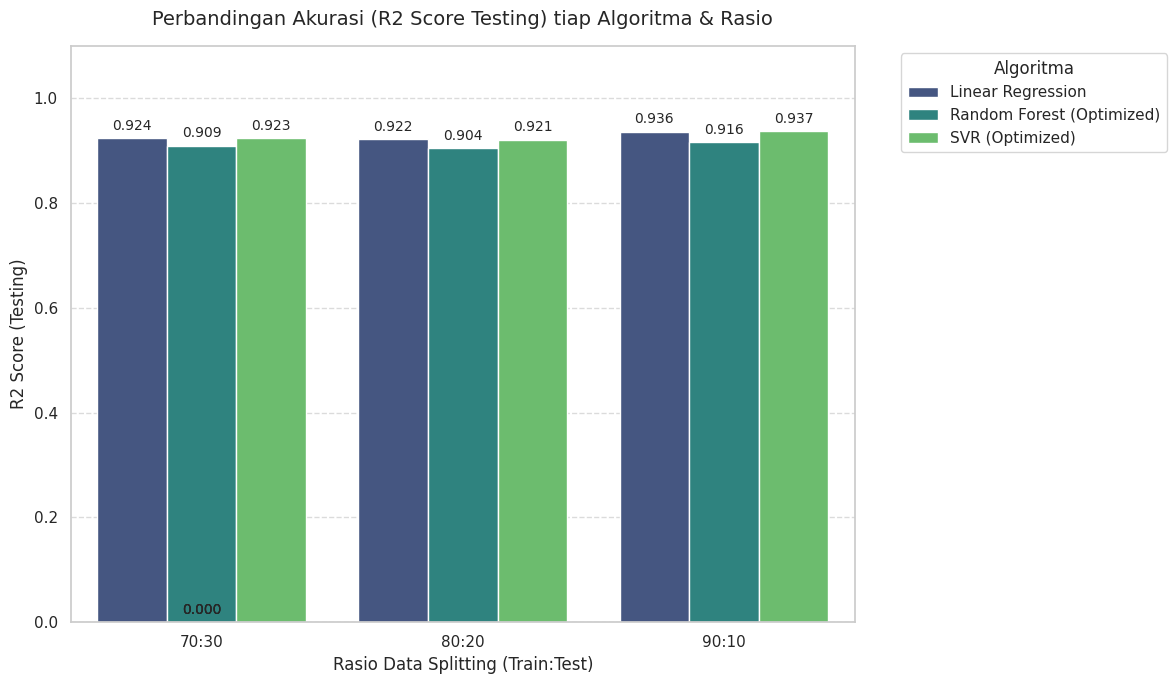

In [93]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Ratio', y='R2_Test', hue='Algorithm', data=df_comparison, palette='viridis')

plt.title('Perbandingan Akurasi (R2 Score Testing) tiap Algoritma & Rasio', fontsize=14, pad=15)
plt.xlabel('Rasio Data Splitting (Train:Test)', fontsize=12)
plt.ylabel('R2 Score (Testing)', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(title='Algoritma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

# **INFERENCE**

In [95]:
def predict_new_data():
    print("=== APLIKASI PREDIKSI PERTUMBUHAN JAGUNG (OPTIMIZED) ===")
    best_algo_name = df_comparison_sorted.iloc[0]['Algorithm']
    best_ratio = df_comparison_sorted.iloc[0]['Ratio']
    if 'SVR' in best_algo_name:
        model_final = next(item['Model'] for item in results_svr_after if item['Ratio'] == best_ratio)
    elif 'Random Forest' in best_algo_name:
        model_final = next(item['Model'] for item in results_rf_after if item['Ratio'] == best_ratio)
    else:
        model_final = lr_model

    try:
        # 3. Input Data Baru
        temp = float(input("Masukkan Suhu (°C): "))
        hum = float(input("Masukkan Kelembapan (%): "))
        soil = float(input("Masukkan Kelembapan Tanah (%): "))
        new_data = pd.DataFrame([[temp, hum, soil]], columns=['Temperature', 'Humidity', 'Soil_Moisture'])
        new_data_poly = poly.transform(new_data)
        if best_ratio == "70:30":
            current_scaler = scaler70
        elif best_ratio == "80:20":
            current_scaler = scaler80
        else:
            current_scaler = scaler90

        new_data_scaled = current_scaler.transform(new_data_poly)

        # 5. Eksekusi Prediksi
        res = model_final.predict(new_data_scaled)

        print("\n" + "="*45)
        print(f"ALGORITMA DIGUNAKAN : {best_algo_name}")
        print(f"ESTIMASI PERTUMBUHAN: {res[0]:.2f} cm") # Hapus "/hari" agar lebih aman
        print(f"Batas Toleransi Error (MAE): ±{best_overall['MAE']:.2f} cm")
        print("="*45)

    except ValueError:
        print("Error: Harap masukkan angka yang valid.")
    except Exception as e:
        print(f"Terjadi kesalahan teknis: {e}")

# Jalankan fungsi inference
predict_new_data()

=== APLIKASI PREDIKSI PERTUMBUHAN JAGUNG (OPTIMIZED) ===
Masukkan Suhu (°C): 11
Masukkan Kelembapan (%): 52
Masukkan Kelembapan Tanah (%): 20

ALGORITMA DIGUNAKAN : SVR (Optimized)
ESTIMASI PERTUMBUHAN: 64.65 cm
Batas Toleransi Error (MAE): ±4.09 cm
